1.Data Preparation

In [2]:
# Import File
import pandas as pd
import numpy as np

file_path = "C:\\Users\\Acer\\OneDrive - Asia Pacific University\\Degree Y3S2\\FYP\\traffic_accidents.csv"
df = pd.read_csv(file_path)

In [3]:
# dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209306 entries, 0 to 209305
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   crash_date                     209306 non-null  object
 1   traffic_control_device         209306 non-null  object
 2   weather_condition              209306 non-null  object
 3   lighting_condition             209306 non-null  object
 4   first_crash_type               209306 non-null  object
 5   trafficway_type                209306 non-null  object
 6   alignment                      209306 non-null  object
 7   roadway_surface_cond           209306 non-null  object
 8   road_defect                    209306 non-null  object
 9   crash_type                     209306 non-null  object
 10  intersection_related_i         209306 non-null  object
 11  damage                         209306 non-null  object
 12  prim_contributory_cause        209306 non-nu

In [4]:
# description statistic
df.describe()

,num_units,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
count,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000
mean,2.063300,0.382717,0.001859,0.038102,0.221241,0.121516,2.244002,13.373047,4.144024,6.771822
std,0.396012,0.799720,0.047502,0.233964,0.614960,0.450865,1.241175,5.603830,1.966864,3.427593
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,9.000000,2.000000,4.000000
50%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,14.000000,4.000000,7.000000
75%,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000,17.000000,6.000000,10.000000
max,11.000000,21.000000,3.000000,7.000000,21.000000,15.000000,49.000000,23.000000,7.000000,12.000000


In [5]:
# Filter for Intersections ONLY
# check for missing values
df = df[df['intersection_related_i'] == 'Y'].copy()
df.isnull().sum()

crash_date                       0
traffic_control_device           0
weather_condition                0
lighting_condition               0
first_crash_type                 0
trafficway_type                  0
alignment                        0
roadway_surface_cond             0
road_defect                      0
crash_type                       0
intersection_related_i           0
damage                           0
prim_contributory_cause          0
num_units                        0
most_severe_injury               0
injuries_total                   0
injuries_fatal                   0
injuries_incapacitating          0
injuries_non_incapacitating      0
injuries_reported_not_evident    0
injuries_no_indication           0
crash_hour                       0
crash_day_of_week                0
crash_month                      0
dtype: int64

In [6]:
# Check UNKNOWN counts
unknown_cols = ['roadway_surface_cond', 'road_defect', 'traffic_control_device', 
                'weather_condition', 'alignment']
for col in unknown_cols:
    count = (df[col] == 'UNKNOWN').sum()
    print(f"{col}: {count}")

roadway_surface_cond: 11822
road_defect: 32586
traffic_control_device: 4035
weather_condition: 6162
alignment: 0


In [7]:
# List the specific text values that act as "hidden" missing data
hidden_nulls = ['UNKNOWN', 'UNABLE TO DETERMINE']

# Count how many times these hidden nulls appear in each column
unknown_counts = df.isin(hidden_nulls).sum()

# Filter to only show columns that actually have at least one 'UNKNOWN'
# and sort them from highest count to lowest
unknown_counts_filtered = unknown_counts[unknown_counts > 0].sort_values(ascending=False)

print("Count of 'UNKNOWN' or 'UNABLE TO DETERMINE' per column:")
print("-" * 55)
# Print the results
if not unknown_counts_filtered.empty:
    print(unknown_counts_filtered)
else:
    print("No 'UNKNOWN' values found in any column!")

Count of 'UNKNOWN' or 'UNABLE TO DETERMINE' per column:
-------------------------------------------------------
prim_contributory_cause    55193
road_defect                32586
roadway_surface_cond       11822
weather_condition           6162
lighting_condition          4055
traffic_control_device      4035
trafficway_type              963
dtype: int64


In [8]:
# check duplicate records

num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 30


Distribution Analysis

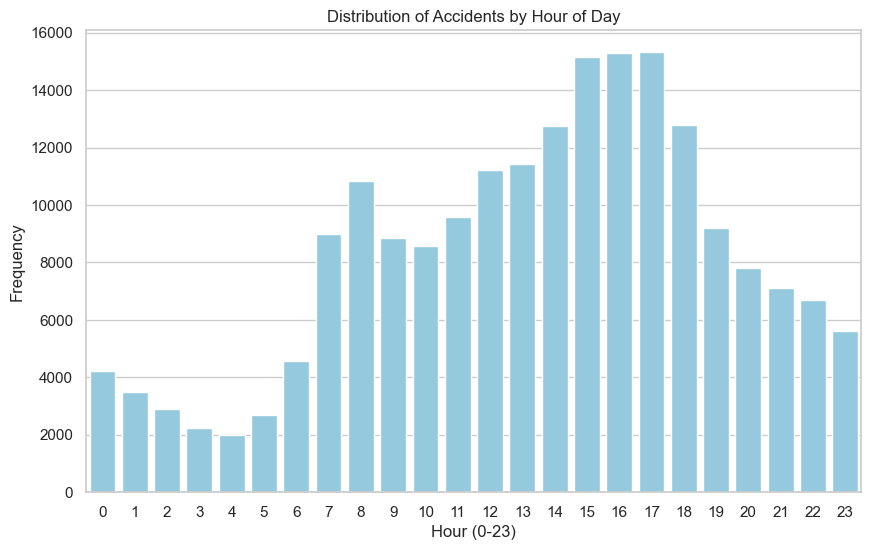

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 1. Distribution of Crash Hour
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='crash_hour', color='skyblue')
plt.title('Distribution of Accidents by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Frequency')
plt.show()

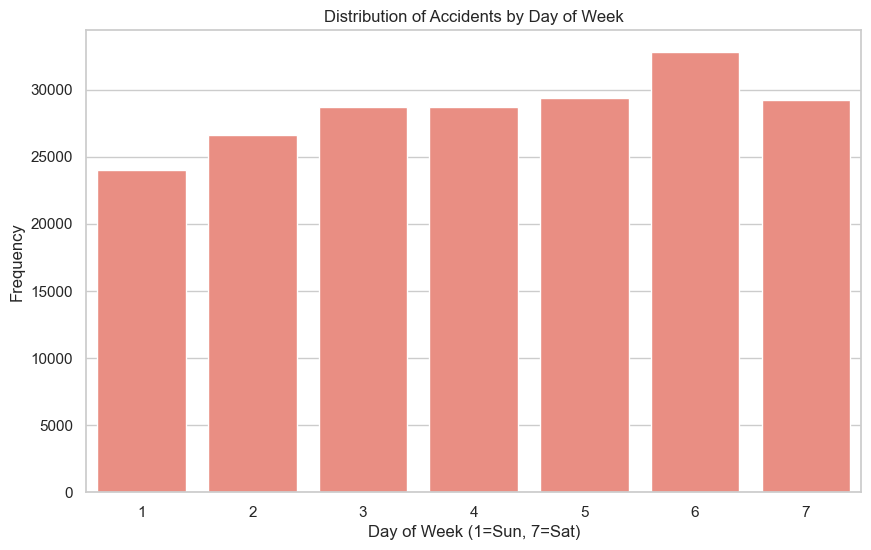

In [10]:
# 2. Distribution of Crash Day of Week
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='crash_day_of_week', color='salmon')
plt.title('Distribution of Accidents by Day of Week')
plt.xlabel('Day of Week (1=Sun, 7=Sat)')
plt.ylabel('Frequency')
plt.show()

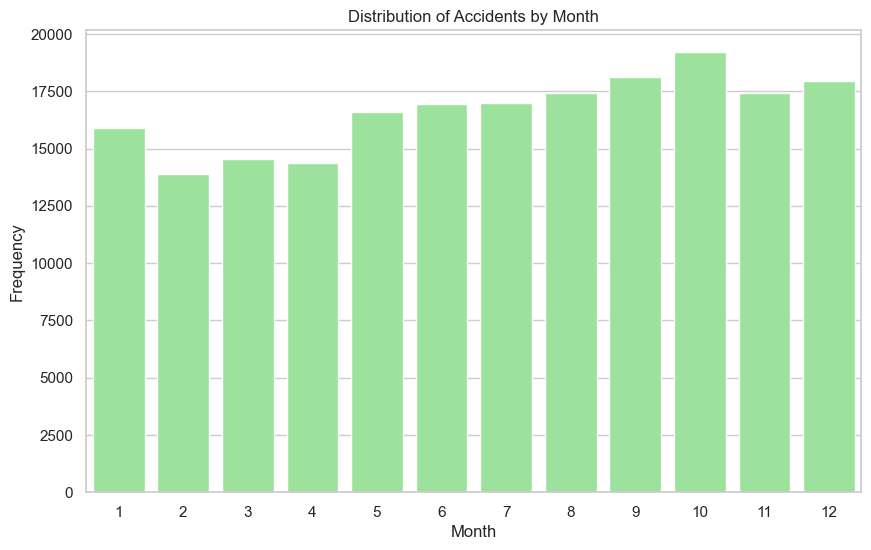

In [11]:
# 3. Distribution of Crash Month
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='crash_month', color='lightgreen')
plt.title('Distribution of Accidents by Month')
plt.xlabel('Month')
plt.ylabel('Frequency')
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_19440\3252236055.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='damage', order=df['damage'].value_counts().index, palette='viridis')


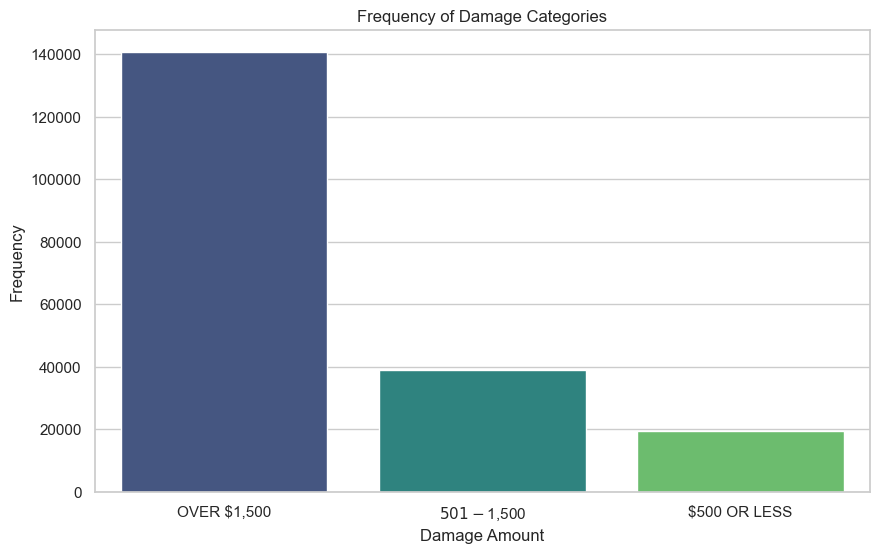

In [12]:
# 4. Damage Categories
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='damage', order=df['damage'].value_counts().index, palette='viridis')
plt.title('Frequency of Damage Categories')
plt.xlabel('Damage Amount')
plt.ylabel('Frequency')
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_19440\3377213309.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_weather.values, y=top_weather.index, palette='magma')


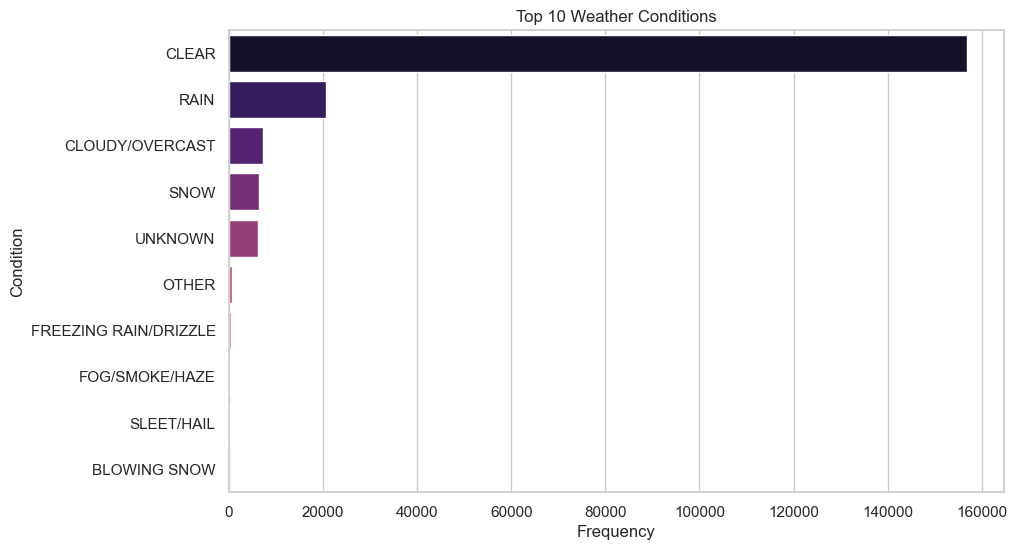

In [13]:
# 5. Weather Conditions (Top 10)
plt.figure(figsize=(10,6))
top_weather = df['weather_condition'].value_counts().head(10)
sns.barplot(x=top_weather.values, y=top_weather.index, palette='magma')
plt.title('Top 10 Weather Conditions')
plt.xlabel('Frequency')
plt.ylabel('Condition')
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_19440\3427289506.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='lighting_condition',


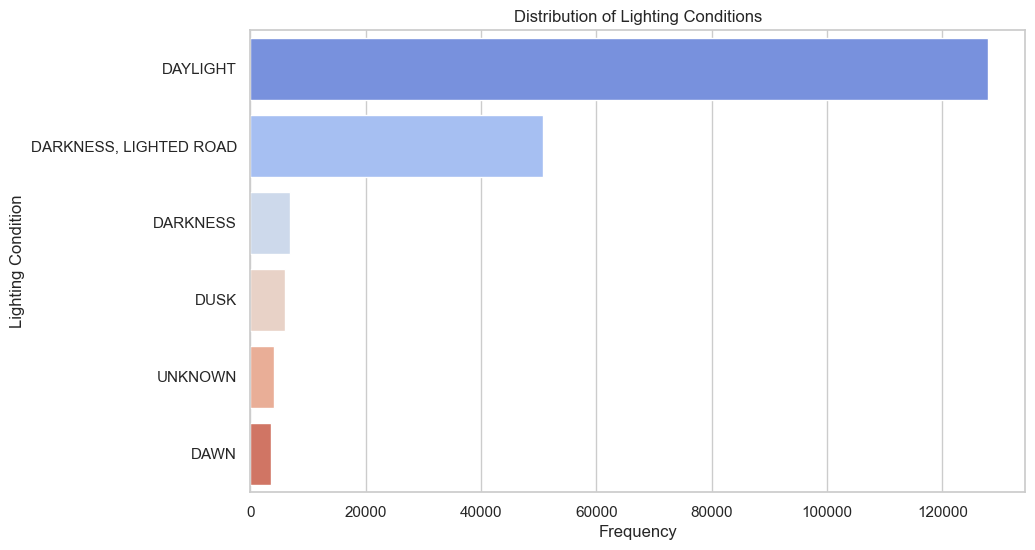

In [14]:
# 6. Lighting Conditions
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='lighting_condition',
              order=df['lighting_condition'].value_counts().index,
              palette='coolwarm')
plt.title('Distribution of Lighting Conditions')
plt.xlabel('Frequency')
plt.ylabel('Lighting Condition')
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_19440\1050191591.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=injury_summary.index, y=injury_summary.values, palette="Blues_r")


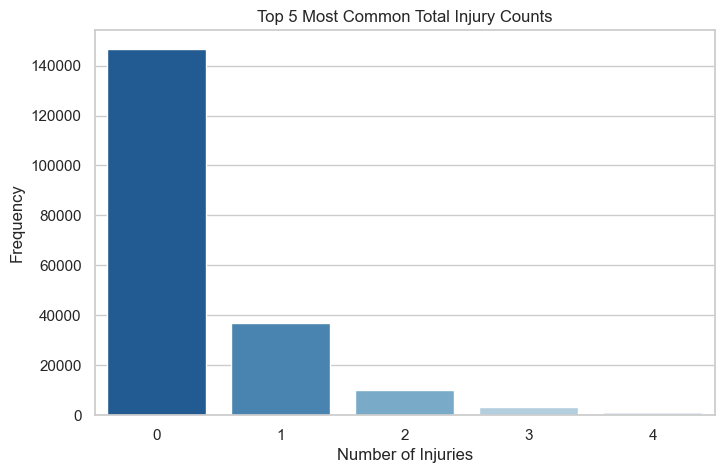

In [15]:
# Injury distribution summary
injury_summary = df['injuries_total'].value_counts().head(5)

plt.figure(figsize=(8,5))
sns.barplot(x=injury_summary.index, y=injury_summary.values, palette="Blues_r")

plt.title("Top 5 Most Common Total Injury Counts")
plt.xlabel("Number of Injuries")
plt.ylabel("Frequency")
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_19440\914879225.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='most_severe_injury', order=df['most_severe_injury'].value_counts().index, palette='viridis')


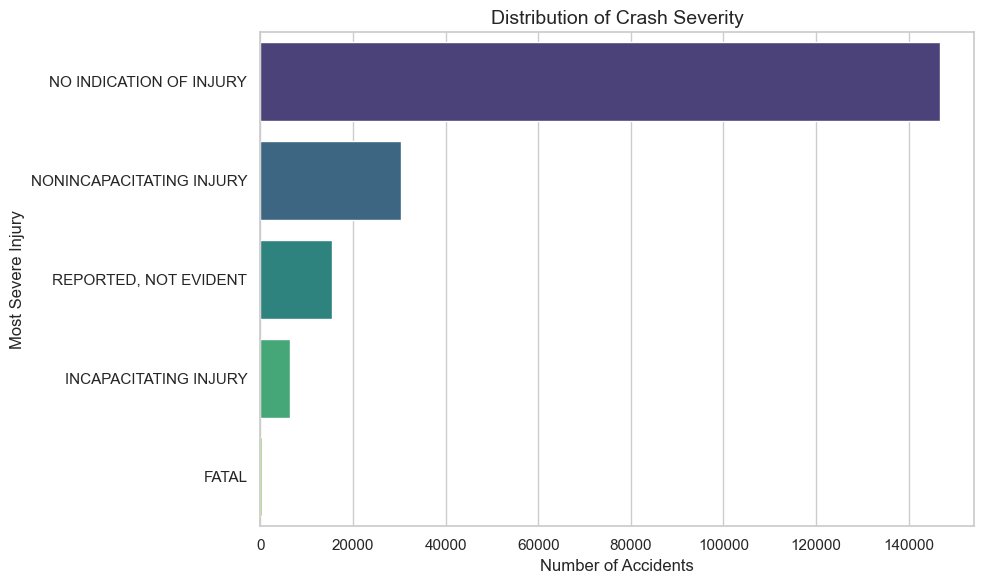

Severity Percentages:
most_severe_injury
NO INDICATION OF INJURY     73.645923
NONINCAPACITATING INJURY    15.261082
REPORTED, NOT EVIDENT        7.764243
INCAPACITATING INJURY        3.165700
FATAL                        0.163051
Name: proportion, dtype: float64


In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='most_severe_injury', order=df['most_severe_injury'].value_counts().index, palette='viridis')

plt.title('Distribution of Crash Severity', fontsize=14)
plt.xlabel('Number of Accidents', fontsize=12)
plt.ylabel('Most Severe Injury', fontsize=12)
plt.tight_layout()
plt.show()

# Print the exact percentages
print("Severity Percentages:")
print(df['most_severe_injury'].value_counts(normalize=True) * 100)

['num_units', 'injuries_total', 'injuries_fatal', 'injuries_incapacitating', 'injuries_non_incapacitating', 'injuries_reported_not_evident', 'injuries_no_indication', 'crash_hour', 'crash_day_of_week', 'crash_month']
                               num_units  injuries_total  injuries_fatal  \
num_units                       1.000000        0.162810        0.030927   
injuries_total                  0.162810        1.000000        0.098514   
injuries_fatal                  0.030927        0.098514        1.000000   
injuries_incapacitating         0.071685        0.322204        0.050418   
injuries_non_incapacitating     0.123721        0.769296        0.027529   
injuries_reported_not_evident   0.079557        0.546376        0.007625   
injuries_no_indication          0.185490       -0.323779       -0.032869   
crash_hour                      0.015500       -0.016365       -0.005451   
crash_day_of_week               0.002166       -0.015858       -0.001411   
crash_month            

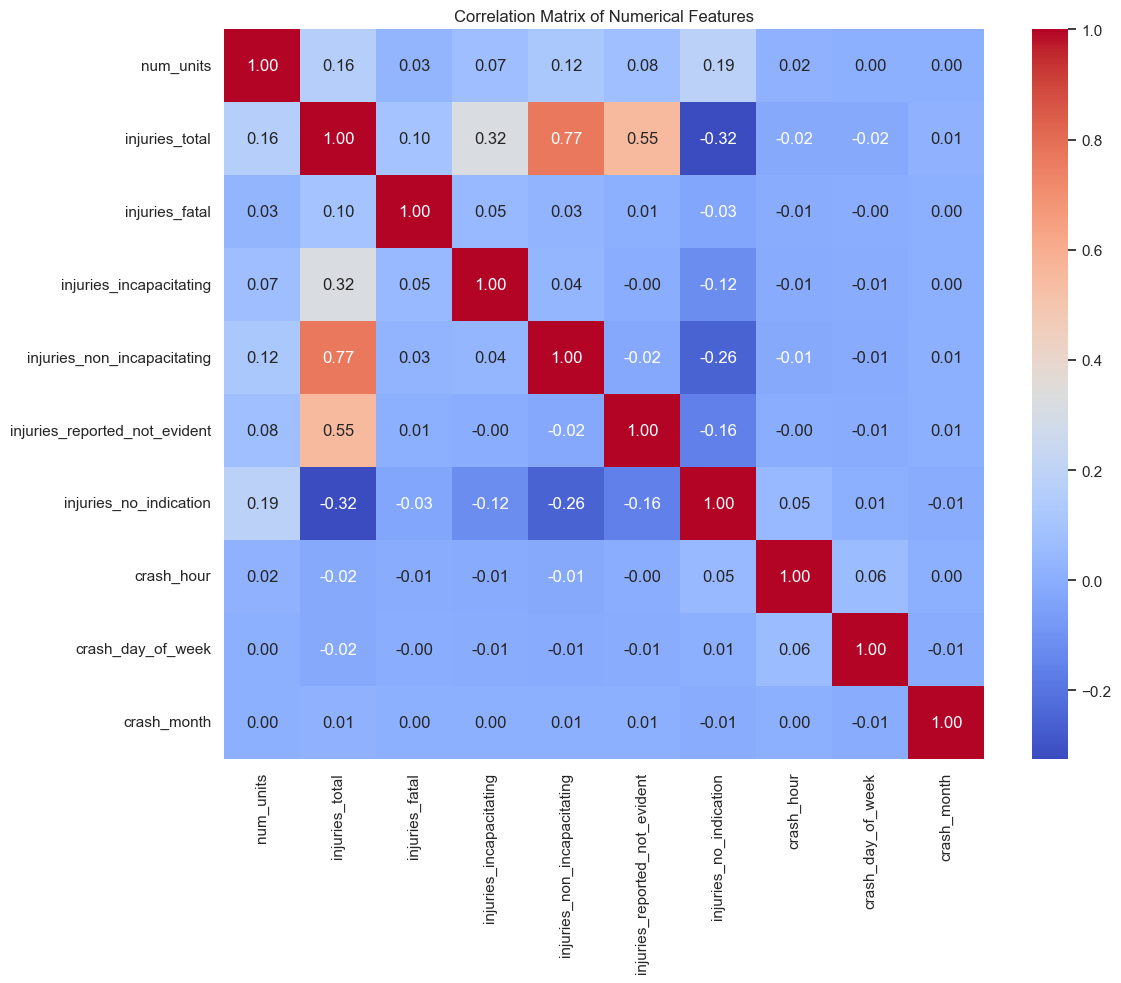

In [17]:
# Correlation heatmap
numerical_df = df.select_dtypes(include=[np.number])

corr_matrix = numerical_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.savefig('correlation_matrix.png')

print(numerical_df.columns.tolist())
print(corr_matrix)

Data Preprocessing

In [9]:
# Handle 'UNKNOWN' values
unknown_cols = [
    'weather_condition', 'lighting_condition', 'roadway_surface_cond', 
    'road_defect', 'traffic_control_device', 'alignment', 'trafficway_type'
]

for col in unknown_cols:
    df[col] = df[col].astype(str).str.strip().str.upper()
    df[col] = df[col].replace('UNKNOWN', np.nan)

rows_before = df.shape[0]
df = df.dropna(subset=unknown_cols)
print(f"Rows removed due to UNKNOWN: {rows_before - df.shape[0]}")
print(f"Final shape: {df.shape}")

Rows removed due to UNKNOWN: 35621
Final shape: (163703, 24)


In [10]:
# Remove duplicate records
print(f"\nShape before removing duplicates: {df.shape}")
df = df.drop_duplicates(keep='first')
print(f"Shape after removing duplicates: {df.shape}")

# Final verification
print(f"Duplicates remaining: {df.duplicated().sum()}")


Shape before removing duplicates: (163703, 24)
Shape after removing duplicates: (163676, 24)
Duplicates remaining: 0


In [11]:
# Reset index
df = df.reset_index(drop=True)
print(f"Index reset complete.")
print(f"Total rows: {len(df)}")

Index reset complete.
Total rows: 163676


In [12]:
# Target Variable: Assign Risk Levels
def assign_risk(row):
    # High Risk
    if row['injuries_fatal'] > 0 or row['most_severe_injury'] == 'FATAL':
        return 2
    elif row['injuries_incapacitating'] > 0 or row['most_severe_injury'] == 'INCAPACITATING INJURY':
        return 2
    
    # Medium Risk
    elif row['most_severe_injury'] in ['NONINCAPACITATING INJURY', 'REPORTED, NOT EVIDENT']:
        return 1
    elif row['damage'] == 'OVER $1,500' and row['injuries_total'] > 0:
        return 1
    
    # Low Risk
    else:
        return 0
    
# Apply the function to create the new target column
df['Risk_Level'] = df.apply(assign_risk, axis=1)

# Verify the distribution
print(df['Risk_Level'].value_counts())

Risk_Level
0    119315
1     38641
2      5720
Name: count, dtype: int64


Risk Level Distribution:
----------------------------------------
  Low Risk (class 0): 119,315  (72.9%)
  Medium Risk (class 1): 38,641  (23.6%)
  High Risk (class 2):  5,720  (3.5%)

  Total records: 163,676

Imbalance Assessment:
  ⚠ WARNING — Minority class is only 3.5%. Apply SMOTE or class_weight='balanced' during training.


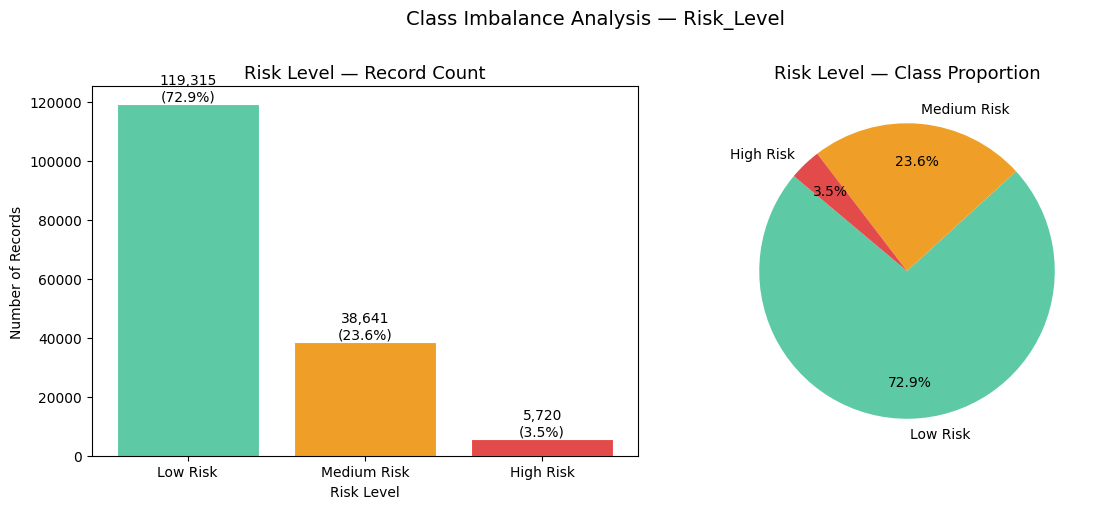

In [13]:
# Check class imbalance
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Count and percentage breakdown
risk_counts = df['Risk_Level'].value_counts().sort_index()
risk_pct    = df['Risk_Level'].value_counts(normalize=True).sort_index() * 100

risk_labels = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}
colors      = ['#5DCAA5', '#EF9F27', '#E24B4A']

print("Risk Level Distribution:")
print("-" * 40)
for level in [0, 1, 2]:
    print(f"  {risk_labels[level]} (class {level}): "
          f"{risk_counts[level]:>6,}  ({risk_pct[level]:.1f}%)")
print(f"\n  Total records: {len(df):,}")

# Flag imbalance warning
dominant = risk_pct.max()
minority = risk_pct.min()
print("\nImbalance Assessment:")
if minority < 15:
    print(f"  ⚠ WARNING — Minority class is only {minority:.1f}%. "
          "Apply SMOTE or class_weight='balanced' during training.")
else:
    print(f"  ✓ Class distribution is acceptable "
          f"(min class = {minority:.1f}%).")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar([risk_labels[i] for i in [0,1,2]],
            [risk_counts[i] for i in [0,1,2]],
            color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Risk Level — Record Count', fontsize=13)
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Number of Records')
for i, (cnt, pct) in enumerate(zip([risk_counts[j] for j in [0,1,2]],
                                    [risk_pct[j]    for j in [0,1,2]])):
    axes[0].text(i, cnt + risk_counts.max() * 0.01,
                 f'{cnt:,}\n({pct:.1f}%)', ha='center', fontsize=10)

# Pie chart
axes[1].pie([risk_counts[i] for i in [0,1,2]],
            labels=[risk_labels[i] for i in [0,1,2]],
            autopct='%1.1f%%', colors=colors,
            startangle=140, pctdistance=0.75)
axes[1].set_title('Risk Level — Class Proportion', fontsize=13)

plt.suptitle('Class Imbalance Analysis — Risk_Level', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Selected variables to PREDICT the target
selected_features = [
    'weather_condition', 'lighting_condition', 'roadway_surface_cond',
    'road_defect', 'alignment', 'traffic_control_device', 'trafficway_type',
    'crash_hour', 'crash_day_of_week', 'crash_month'
]

X = df[selected_features]
y = df['Risk_Level']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (163676, 10)
y shape: (163676,)


In [15]:
from scipy.stats import chi2_contingency

#  categorical environmental features
categorical_features = [
    'weather_condition', 'lighting_condition', 'roadway_surface_cond', 
    'road_defect', 'alignment', 'traffic_control_device', 'trafficway_type'
]

# target variable
target = 'Risk_Level'

# Create an empty list to store the results
results = []

# 3. Loop through each feature and test its relationship with Risk_Level
for col in categorical_features:
    # Create the contingency table (a matrix of frequencies)
    contingency_table = pd.crosstab(df[col], df[target])
    
    # Run the Chi-Square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    # Append the results
    results.append({
        'Feature': col,
        'Chi-Square Statistic': round(chi2, 2),
        'P-Value': p,
        # We use a standard alpha level of 0.05 (95% confidence)
        'Significant?': 'Yes' if p < 0.05 else 'No' 
    })

# 4. Format and display the results
chi_square_df = pd.DataFrame(results)

# Sort from strongest relationship (highest statistic) to weakest
chi_square_df = chi_square_df.sort_values(by='Chi-Square Statistic', ascending=False)

print("Chi-Square Test Results: Feature vs. Risk_Level")
print("-" * 65)
print(chi_square_df.to_string(index=False))

# Optional: Save it to a CSV to easily copy into your FYP report
chi_square_df.to_csv('chi_square_results.csv', index=False)

Chi-Square Test Results: Feature vs. Risk_Level
-----------------------------------------------------------------
               Feature  Chi-Square Statistic       P-Value Significant?
       trafficway_type               1516.65 1.199788e-295          Yes
traffic_control_device                398.78  8.265327e-64          Yes
    lighting_condition                309.18  4.566959e-62          Yes
  roadway_surface_cond                205.54  1.128456e-38          Yes
     weather_condition                142.52  1.679074e-20          Yes
           road_defect                 59.33  4.843077e-09          Yes
             alignment                 23.66  8.547913e-03          Yes


One-Way ANOVA: Numerical Features vs. Risk_Level
------------------------------------------------------------
  crash_hour             F= 15.5752   p=0.000000   Significant: Yes
  crash_day_of_week      F= 17.6972   p=0.000000   Significant: Yes
  crash_month            F= 19.6856   p=0.000000   Significant: Yes

Point-Biserial Correlation: Numerical Features vs. Each Risk Class
----------------------------------------------------------------------
  Feature                  vs Low (0)  vs Medium (1)  vs High (2)
  --------------------------------------------------------------
  crash_hour             r=+0.0130 (p=0.0000) r=-0.0100 (p=0.0000) r=-0.0084 (p=0.0007)
  crash_day_of_week      r=+0.0146 (p=0.0000) r=-0.0128 (p=0.0000) r=-0.0058 (p=0.0190)
  crash_month            r=-0.0155 (p=0.0000) r=+0.0139 (p=0.0000) r=+0.0053 (p=0.0325)


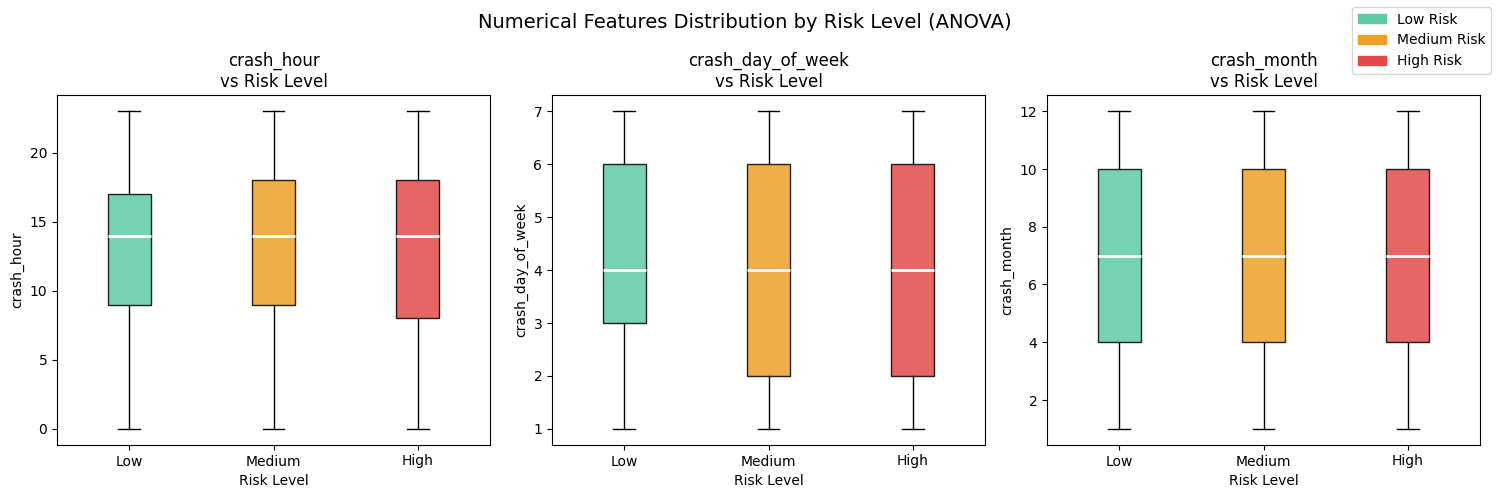

In [16]:
# Statistical tests for numerical features 
from scipy.stats import f_oneway, pointbiserialr
import warnings
warnings.filterwarnings('ignore')

numerical_features = ['crash_hour', 'crash_day_of_week', 'crash_month']

# One-Way ANOVA 
# Tests whether the mean of each numerical feature differs significantly
# across the three Risk_Level classes (Low=0, Medium=1, High=2).
print("One-Way ANOVA: Numerical Features vs. Risk_Level")
print("-" * 60)

anova_results = []
for col in numerical_features:
    groups = [df[df['Risk_Level'] == level][col].values for level in [0, 1, 2]]
    f_stat, p_val = f_oneway(*groups)
    significant = 'Yes' if p_val < 0.05 else 'No'
    anova_results.append({
        'Feature': col,
        'F-Statistic': round(f_stat, 4),
        'P-Value': round(p_val, 6),
        'Significant?': significant
    })
    print(f"  {col:<22} F={f_stat:>8.4f}   p={p_val:.6f}   "
          f"Significant: {significant}")

anova_df = pd.DataFrame(anova_results)



# Point-Biserial Correlation (each class vs. feature)
print("\nPoint-Biserial Correlation: Numerical Features vs. Each Risk Class")
print("-" * 70)
print(f"  {'Feature':<22} {'vs Low (0)':>12} {'vs Medium (1)':>14} {'vs High (2)':>12}")
print("  " + "-" * 62)

pb_results = []
for col in numerical_features:
    row = {'Feature': col}
    corrs = []
    for level in [0, 1, 2]:
        binary_target = (df['Risk_Level'] == level).astype(int)
        r, p = pointbiserialr(df[col], binary_target)
        row[f'Class_{level}_r'] = round(r, 4)
        row[f'Class_{level}_p'] = round(p, 6)
        corrs.append(f"r={r:+.4f} (p={p:.4f})")
    pb_results.append(row)
    print(f"  {col:<22} {corrs[0]:>20} {corrs[1]:>20} {corrs[2]:>20}")

    

pb_df = pd.DataFrame(pb_results)

# Visualise — boxplots of numerical features by Risk Level
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors_box = {0: '#5DCAA5', 1: '#EF9F27', 2: '#E24B4A'}
labels_box  = {0: 'Low', 1: 'Medium', 2: 'High'}

for ax, col in zip(axes, numerical_features):
    data_by_class = [df[df['Risk_Level'] == level][col].values
                     for level in [0, 1, 2]]
    bp = ax.boxplot(data_by_class, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2))
    for patch, level in zip(bp['boxes'], [0, 1, 2]):
        patch.set_facecolor(colors_box[level])
        patch.set_alpha(0.85)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels([labels_box[i] for i in [0, 1, 2]])
    ax.set_title(f'{col}\nvs Risk Level', fontsize=12)
    ax.set_xlabel('Risk Level')
    ax.set_ylabel(col)

patches = [mpatches.Patch(color=colors_box[i], label=f'{labels_box[i]} Risk')
           for i in [0, 1, 2]]
fig.legend(handles=patches, loc='upper right', fontsize=10)
plt.suptitle('Numerical Features Distribution by Risk Level (ANOVA)', fontsize=14)
plt.tight_layout()
plt.savefig('anova_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

Train/Test Split

In [17]:

from sklearn.model_selection import train_test_split

# Split 1 — 80% train / 20% test
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Split 1 — 80/20")
print("-" * 50)
print(f"  X_train : {X_train_80.shape}")
print(f"  X_test  : {X_test_80.shape}")
print(f"  y_train : {y_train_80.shape}")
print(f"  y_test  : {y_test_80.shape}")

print("\n  Training set class distribution:")
for level, label in {0:'Low', 1:'Medium', 2:'High'}.items():
    cnt = (y_train_80 == level).sum()
    pct = cnt / len(y_train_80) * 100
    print(f"    {label} Risk (class {level}): {cnt:>6,}  ({pct:.1f}%)")

print("\n  Test set class distribution:")
for level, label in {0:'Low', 1:'Medium', 2:'High'}.items():
    cnt = (y_test_80 == level).sum()
    pct = cnt / len(y_test_80) * 100
    print(f"    {label} Risk (class {level}): {cnt:>6,}  ({pct:.1f}%)")

Split 1 — 80/20
--------------------------------------------------
  X_train : (130940, 10)
  X_test  : (32736, 10)
  y_train : (130940,)
  y_test  : (32736,)

  Training set class distribution:
    Low Risk (class 0): 95,451  (72.9%)
    Medium Risk (class 1): 30,913  (23.6%)
    High Risk (class 2):  4,576  (3.5%)

  Test set class distribution:
    Low Risk (class 0): 23,864  (72.9%)
    Medium Risk (class 1):  7,728  (23.6%)
    High Risk (class 2):  1,144  (3.5%)


In [18]:
# Split 2 — 70% train / 30% test
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Split 2 — 70/30")
print("-" * 50)
print(f"  X_train : {X_train_70.shape}")
print(f"  X_test  : {X_test_70.shape}")
print(f"  y_train : {y_train_70.shape}")
print(f"  y_test  : {y_test_70.shape}")

print("\n  Training set class distribution:")
for level, label in {0:'Low', 1:'Medium', 2:'High'}.items():
    cnt = (y_train_70 == level).sum()
    pct = cnt / len(y_train_70) * 100
    print(f"    {label} Risk (class {level}): {cnt:>6,}  ({pct:.1f}%)")

print("\n  Test set class distribution:")
for level, label in {0:'Low', 1:'Medium', 2:'High'}.items():
    cnt = (y_test_70 == level).sum()
    pct = cnt / len(y_test_70) * 100
    print(f"    {label} Risk (class {level}): {cnt:>6,}  ({pct:.1f}%)")

Split 2 — 70/30
--------------------------------------------------
  X_train : (114573, 10)
  X_test  : (49103, 10)
  y_train : (114573,)
  y_test  : (49103,)

  Training set class distribution:
    Low Risk (class 0): 83,520  (72.9%)
    Medium Risk (class 1): 27,049  (23.6%)
    High Risk (class 2):  4,004  (3.5%)

  Test set class distribution:
    Low Risk (class 0): 35,795  (72.9%)
    Medium Risk (class 1): 11,592  (23.6%)
    High Risk (class 2):  1,716  (3.5%)


In [19]:
#  summary
print("Split Comparison Summary")
print("=" * 55)
print(f"  {'Set':<18} {'80/20 Split':>16} {'70/30 Split':>16}")
print("  " + "-" * 52)
print(f"  {'X_train':<18} {str(X_train_80.shape):>16} {str(X_train_70.shape):>16}")
print(f"  {'X_test':<18} {str(X_test_80.shape):>16} {str(X_test_70.shape):>16}")
print(f"  {'Stratified':<18} {'Yes':>16} {'Yes':>16}")
print(f"  {'random_state':<18} {'42':>16} {'42':>16}")

Split Comparison Summary
  Set                     80/20 Split      70/30 Split
  ----------------------------------------------------
  X_train                (130940, 10)     (114573, 10)
  X_test                  (32736, 10)      (49103, 10)
  Stratified                      Yes              Yes
  random_state                     42               42


Class Imbalance Handling (SMOTE)

In [20]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

# define columns
numerical_cols = [ 'crash_hour', 'crash_day_of_week', 'crash_month']
categorical_cols = ['weather_condition', 'lighting_condition', 'roadway_surface_cond', 
                    'road_defect', 'alignment', 'traffic_control_device', 'trafficway_type']

# For Logistic Regression: Standard Scaler + One-Hot Encoding
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

# For Random Forest / Trees: Standard Scaler + Ordinal Encoding
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
    ])

# 3. ENCODE AND SCALE THE DATA
# We fit on the training data, and transform both train and test
print("Transforming 80/20 split data...")
X_train_80_lr = preprocessor_lr.fit_transform(X_train_80)
X_test_80_lr = preprocessor_lr.transform(X_test_80)

X_train_80_tree = preprocessor_tree.fit_transform(X_train_80)
X_test_80_tree = preprocessor_tree.transform(X_test_80)

# 4. APPLY SMOTE
# Initialize SMOTE
smote = SMOTE(random_state=42)

print("Applying SMOTE to training data...\n")
# Balance the Logistic Regression dataset
X_train_80_lr_bal, y_train_80_bal = smote.fit_resample(X_train_80_lr, y_train_80)

# Balance the Tree dataset (Using the exact same target variable y_train_80)
X_train_80_tree_bal, _ = smote.fit_resample(X_train_80_tree, y_train_80)

# 5. VERIFY THE RESULTS
print("-" * 50)
print("AFTER SMOTE: 80% Training Set Class Distribution")
print("-" * 50)
for level, label in {0:'Low', 1:'Medium', 2:'High'}.items():
    # Since y_train_80 might be a pandas series, we convert to numpy to count easily
    cnt = (np.array(y_train_80_bal) == level).sum()
    pct = cnt / len(y_train_80_bal) * 100
    print(f"    {label} Risk (class {level}): {cnt:>6,}  ({pct:.1f}%)")
    
print(f"\nFinal encoded matrix shape (LR): {X_train_80_lr_bal.shape}")
print(f"Final encoded matrix shape (Tree): {X_train_80_tree_bal.shape}")

Transforming 80/20 split data...
Applying SMOTE to training data...

--------------------------------------------------
AFTER SMOTE: 80% Training Set Class Distribution
--------------------------------------------------
    Low Risk (class 0): 95,451  (33.3%)
    Medium Risk (class 1): 95,451  (33.3%)
    High Risk (class 2): 95,451  (33.3%)

Final encoded matrix shape (LR): (286353, 67)
Final encoded matrix shape (Tree): (286353, 10)


In [21]:
# ── 70/30 split ──────────────────────────────────────────────────────────────
# Re-initialise preprocessors — must refit on new training set
preprocessor_lr_70 = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])
preprocessor_tree_70 = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
])

print("Transforming 70/30 split data...")
X_train_70_lr   = preprocessor_lr_70.fit_transform(X_train_70)
X_test_70_lr    = preprocessor_lr_70.transform(X_test_70)
X_train_70_tree = preprocessor_tree_70.fit_transform(X_train_70)
X_test_70_tree  = preprocessor_tree_70.transform(X_test_70)

print("Applying SMOTE to training data...\n")
X_train_70_lr_bal,   y_train_70_bal = smote.fit_resample(X_train_70_lr,   y_train_70)
X_train_70_tree_bal, _              = smote.fit_resample(X_train_70_tree,  y_train_70)

print("-" * 50)
print("AFTER SMOTE: 70% Training Set Class Distribution")
print("-" * 50)
for level, label in {0:'Low', 1:'Medium', 2:'High'}.items():
    cnt = (np.array(y_train_70_bal) == level).sum()
    pct = cnt / len(y_train_70_bal) * 100
    print(f"    {label} Risk (class {level}): {cnt:>6,}  ({pct:.1f}%)")

print(f"\nFinal encoded matrix shape (LR): {X_train_70_lr_bal.shape}")
print(f"Final encoded matrix shape (Tree): {X_train_70_tree_bal.shape}")

Transforming 70/30 split data...
Applying SMOTE to training data...

--------------------------------------------------
AFTER SMOTE: 70% Training Set Class Distribution
--------------------------------------------------
    Low Risk (class 0): 83,520  (33.3%)
    Medium Risk (class 1): 83,520  (33.3%)
    High Risk (class 2): 83,520  (33.3%)

Final encoded matrix shape (LR): (250560, 67)
Final encoded matrix shape (Tree): (250560, 10)


In [22]:
# Save all data for model training
import joblib

prepared_data = {
    # 80/20 split
    'X_train_80_lr'  : X_train_80_lr_bal,
    'X_train_80_tree': X_train_80_tree_bal,
    'X_test_80_lr'   : X_test_80_lr,
    'X_test_80_tree' : X_test_80_tree,
    'y_train_80'     : y_train_80_bal,
    'y_test_80'      : y_test_80,

    # 70/30 split
    'X_train_70_lr'  : X_train_70_lr_bal,
    'X_train_70_tree': X_train_70_tree_bal,
    'X_test_70_lr'   : X_test_70_lr,
    'X_test_70_tree' : X_test_70_tree,
    'y_train_70'     : y_train_70_bal,
    'y_test_70'      : y_test_70,

    # Preprocessors (needed for dashboard)
    'preprocessor_lr'     : preprocessor_lr,
    'preprocessor_tree'   : preprocessor_tree,
    'preprocessor_lr_70'  : preprocessor_lr_70,
    'preprocessor_tree_70': preprocessor_tree_70,
}

joblib.dump(prepared_data, 'fyp_preprocessed_data.pkl')

print("Saved successfully → fyp_preprocessed_data.pkl")
print("\nKeys saved:")
for k, v in prepared_data.items():
    shape = v.shape if hasattr(v, 'shape') else 'preprocessor object'
    print(f"  {k:<25} : {shape}")

Saved successfully → fyp_preprocessed_data.pkl

Keys saved:
  X_train_80_lr             : (286353, 67)
  X_train_80_tree           : (286353, 10)
  X_test_80_lr              : (32736, 67)
  X_test_80_tree            : (32736, 10)
  y_train_80                : (286353,)
  y_test_80                 : (32736,)
  X_train_70_lr             : (250560, 67)
  X_train_70_tree           : (250560, 10)
  X_test_70_lr              : (49103, 67)
  X_test_70_tree            : (49103, 10)
  y_train_70                : (250560,)
  y_test_70                 : (49103,)
  preprocessor_lr           : preprocessor object
  preprocessor_tree         : preprocessor object
  preprocessor_lr_70        : preprocessor object
  preprocessor_tree_70      : preprocessor object
